<a href="https://colab.research.google.com/github/jerinSabrina/Time_Series_project/blob/main/Data_Mining_Cup_Course/rf_timeseries_h10_holiday_seasonal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Random Forest Time-Series Model — h=10 Working Rows

This notebook builds
1. engineered features
2. trains Random Forest
3. runs time-series CV/random search,
4. validates, tests, and saves SMAPE outputs.

#####Import library

In [22]:

import os
import math
import warnings
from datetime import date, timedelta

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import make_scorer
from scipy.stats import randint


#####Load Data

In [23]:
input_path = "/content/sample_data/eingangsbandwaage_studenten (1).csv"
fraction_path = "/content/sample_data/ballengewichte_studenten (2).csv"

input_df = pd.read_csv(input_path)
fraction_df = pd.read_csv(fraction_path)

print("Input mass shape:", input_df.shape)
print("Fraction shape:", fraction_df.shape)

print("\nInput columns:")
print(input_df.columns.tolist())

print("\nFraction columns:")
print(fraction_df.columns.tolist())

Input mass shape: (1896, 2)
Fraction shape: (1546, 14)

Input columns:
['Zeitstempel', 'Masse']

Fraction columns:
['Datum', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']


######Standardize date columns and merge

In [24]:
# Convert date columns
input_df["Zeitstempel"] = pd.to_datetime(input_df["Zeitstempel"])
fraction_df["Datum"] = pd.to_datetime(fraction_df["Datum"])

# Rename input date column so both files use the same date column
input_df = input_df.rename(columns={"Zeitstempel": "Datum"})

# Define fraction columns
fraction_cols = [str(i) for i in range(1, 15)]

# Merge: keep only dates where fraction data exists
df = fraction_df.merge(input_df, on="Datum", how="left")

# Sort chronologically
df = df.sort_values("Datum").reset_index(drop=True)

print("Merged shape:", df.shape)
print("Date range:", df["Datum"].min(), "to", df["Datum"].max())

display(df.head())

Merged shape: (1546, 15)
Date range: 2020-03-02 00:00:00 to 2024-12-31 00:00:00


,Datum,1,2,3,4,5,6,7,8,9,10,11,12,13,Masse
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.291561
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.638127
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.320958
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,0.013896,0.000000,0.0,0.00000,0.457763
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,0.000000,0.006941,0.0,0.08807,0.544210


In [44]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1546
Columns: 23


#####Add NRW public holiday features

This step adds holiday-related calendar features to the dataset.

NRW public holidays are useful because material input and fraction behavior

may change before, during, or after holidays.

In [25]:
import holidays

years = range(df["Datum"].dt.year.min(), df["Datum"].dt.year.max() + 1)

# NRW = North Rhine-Westphalia, subdivision code "NW"
nrw_holidays = holidays.country_holidays(
    country="DE",
    subdiv="NW",
    years=years
)

df["date_only"] = df["Datum"].dt.date

# Main holiday indicator column
df["is_holiday"] = df["date_only"].isin(nrw_holidays).astype(int)

# More specific name, useful for report clarity
df["is_public_holiday_NRW"] = df["is_holiday"]

# Holiday name
df["holiday_name"] = df["date_only"].map(
    lambda x: nrw_holidays.get(x, "")
)

# Day before and after public holiday
holiday_dates = set(nrw_holidays.keys())

df["is_day_before_holiday"] = df["date_only"].map(
    lambda x: int((pd.Timestamp(x) + pd.Timedelta(days=1)).date() in holiday_dates)
)

df["is_day_after_holiday"] = df["date_only"].map(
    lambda x: int((pd.Timestamp(x) - pd.Timedelta(days=1)).date() in holiday_dates)
)

# Correct fraction_cols to match the actual columns in df
# The original fraction_cols was likely defined to include '14', but the loaded data
# only contains fraction columns '1' through '13'.
fraction_cols = [col for col in df.columns if col.isdigit()]

# Table of all holiday rows before weekend removal
holiday_table_all = df[df["is_holiday"] == 1][
    ["Datum", "holiday_name", "is_holiday", "Masse"] + fraction_cols
].copy()

print("All NRW public holiday rows in fraction dataset:")
display(holiday_table_all)

print("\nHoliday count before weekend removal:", df["is_holiday"].sum())
print("Day-before-holiday count:", df["is_day_before_holiday"].sum())
print("Day-after-holiday count:", df["is_day_after_holiday"].sum())

All NRW public holiday rows in fraction dataset:


,Datum,holiday_name,is_holiday,Masse,1,2,3,4,5,6,7,8,9,10,11,12,13
25,2020-04-10,Good Friday,1,0.185060,0.082660,0.094556,0.142390,0.127620,0.169328,0.074415,0.034470,0.069988,0.053435,0.062771,0.088367,0.000000,0.000000
26,2020-04-13,Easter Monday,1,0.483262,0.148694,0.064995,0.165111,0.058163,0.157998,0.045207,0.022223,0.056304,0.054422,0.102027,0.124855,0.000000,0.000000
44,2020-05-01,Labor Day,1,0.645800,0.172599,0.065813,0.092910,0.055521,0.132217,0.050777,0.021390,0.066014,0.058963,0.175142,0.103678,0.004975,0.000000
64,2020-05-21,Ascension Day,1,0.449232,0.193624,0.060991,0.119256,0.039545,0.140358,0.046393,0.021188,0.049101,0.046958,0.164839,0.108773,0.008973,0.000000
74,2020-06-01,Whit Monday,1,0.503815,0.188259,0.050775,0.130410,0.062297,0.154397,0.027240,0.020895,0.058489,0.057182,0.197237,0.052818,0.000000,0.000000
80,2020-06-11,Corpus Christi,1,0.702709,0.252611,0.069585,0.080130,0.047750,0.127482,0.031643,0.018895,0.066424,0.039492,0.154900,0.102690,0.008398,0.000000
180,2020-10-03,German Unity Day,1,0.168750,0.198078,0.091847,0.073825,0.045696,0.111476,0.064202,0.053357,0.039997,0.080889,0.115640,0.084669,0.040323,0.000000
198,2020-11-01,All Saints' Day,1,0.052009,0.000000,0.200546,0.000000,0.000000,0.120842,0.000000,0.000000,0.086614,0.000000,0.468745,0.123252,0.000000,0.000000
255,2021-01-01,New Year's Day,1,0.048531,0.123885,0.082641,0.170792,0.064212,0.249748,0.031815,0.000000,0.104175,0.068868,0.042174,0.061690,0.000000,0.000000
345,2021-04-02,Good Friday,1,0.215725,0.227650,0.060233,0.110930,0.077584,0.105859,0.040203,0.006889,0.033266,0.039661,0.190987,0.106736,0.000000,0.000000



Holiday count before weekend removal: 36
Day-before-holiday count: 34
Day-after-holiday count: 46


#####Exclude weekends, keep holidays, and clean negative Masse

In [26]:

# Add weekday information before filtering
df["weekday"] = df["Datum"].dt.day_name()
df["weekday_num"] = df["Datum"].dt.dayofweek

# Exclude only Saturday and Sunday
# Important: public holidays on weekdays are kept in the dataset.
work_df = df[df["weekday_num"] < 5].copy().reset_index(drop=True)

# Negative mass is physically impossible, so clip to 0 for modelling
work_df["Masse_original"] = work_df["Masse"]
work_df["Masse"] = work_df["Masse"].clip(lower=0)

print("Shape after weekend removal:", work_df.shape)
print("Date range after weekend removal:", work_df["Datum"].min(), "to", work_df["Datum"].max())

print("\nWeekday counts after weekend removal:")
display(work_df["weekday"].value_counts().sort_index())

# Table of all holidays that remain after weekend removal
holiday_table_workdays = work_df[work_df["is_holiday"] == 1][
    ["Datum", "weekday", "holiday_name", "is_holiday", "Masse"]
].copy()

print("\nNRW public holidays kept after weekend removal:")
display(holiday_table_workdays)

print("\nNumber of weekday public holidays kept:", len(holiday_table_workdays))

print("\nFinal working dataset preview:")
display(work_df.tail())

Shape after weekend removal: (1202, 24)
Date range after weekend removal: 2020-03-02 00:00:00 to 2024-12-31 00:00:00

Weekday counts after weekend removal:


,count
weekday,
Friday,243
Monday,232
Thursday,244
Tuesday,240
Wednesday,243



NRW public holidays kept after weekend removal:


,Datum,weekday,holiday_name,is_holiday,Masse
19,2020-04-10,Friday,Good Friday,1,0.185060
20,2020-04-13,Monday,Easter Monday,1,0.483262
34,2020-05-01,Friday,Labor Day,1,0.645800
48,2020-05-21,Thursday,Ascension Day,1,0.449232
55,2020-06-01,Monday,Whit Monday,1,0.503815
61,2020-06-11,Thursday,Corpus Christi,1,0.702709
198,2021-01-01,Friday,New Year's Day,1,0.048531
263,2021-04-02,Friday,Good Friday,1,0.215725
264,2021-04-05,Monday,Easter Monday,1,0.016547
292,2021-05-13,Thursday,Ascension Day,1,0.722911



Number of weekday public holidays kept: 32

Final working dataset preview:


,Datum,1,2,3,4,5,6,7,8,9,...,Masse,date_only,is_holiday,is_public_holiday_NRW,holiday_name,is_day_before_holiday,is_day_after_holiday,weekday,weekday_num,Masse_original
1197,2024-12-24,0.221623,0.142965,0.127144,0.072535,0.109840,0.048001,0.015443,0.059910,0.047961,...,0.820967,2024-12-24,0,0,,1,0,Tuesday,1,0.820967
1198,2024-12-26,0.227366,0.151756,0.000000,0.000000,0.184199,0.058182,0.000000,0.074716,0.091876,...,0.747486,2024-12-26,1,1,Second Day of Christmas,0,1,Thursday,3,0.747486
1199,2024-12-27,0.263026,0.131817,0.123569,0.068892,0.114085,0.050643,0.010281,0.046770,0.060500,...,0.893760,2024-12-27,0,0,,0,1,Friday,4,0.893760
1200,2024-12-30,0.246167,0.136020,0.110706,0.071743,0.107153,0.043589,0.010769,0.044998,0.053787,...,0.862853,2024-12-30,0,0,,0,0,Monday,0,0.862853
1201,2024-12-31,0.258223,0.101629,0.108412,0.056203,0.112360,0.070415,0.010237,0.047472,0.054964,...,0.796738,2024-12-31,0,0,,0,0,Tuesday,1,0.796738


#####Model configuration

In [27]:
HORIZON = 10                      # 10 working rows ahead
SEASONAL_PERIOD = 252             # approx. one working year
N_SPLITS_CV = 5
RANDOM_STATE = 42                 #makes the Random Forest results reproducible
LAGS = [1, 2, 5, 10, 21, 63, 126] #short-term memory: 1, 2, 5, 10(current fraction depends on last week)  # medium-term memory: 21, 63(last month) # longer-term memory: 126(previous quarter)
ROLLING_WINDOWS = [5, 10, 21, 63] #Rolling features can capture: recent average,recent volatility,recent minimum,recent maximum,recent trend
fraction_cols = [str(i) for i in range(1, 14)]
FRACTION_COLS = fraction_cols
MASS_COL = "Masse"
DATE_COL = "Datum"
# Use fewer iterations to keep runtime reasonable, but still do real tuning.
N_RANDOM_SEARCH_ITER = 4

######Define Function ( SMAPE_NP , SMAPE_per_function, Smape_scorer_func, Postprocess_fraction_prediction )

In [28]:
def smape_np(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return np.mean(200.0 * np.abs(y_pred - y_true) / denom)


def smape_per_fraction_df(y_true, y_pred, fraction_cols=FRACTION_COLS):
    rows = []
    for i, col in enumerate(fraction_cols):
        rows.append({
            "fraction": col,
            "SMAPE": smape_np(y_true[:, i], y_pred[:, i])
        })
    return pd.DataFrame(rows)


def smape_scorer_func(y_true, y_pred):
    return -smape_np(y_true, y_pred)

SMAPE_SCORER = make_scorer(smape_scorer_func, greater_is_better=True)


def postprocess_fraction_predictions(pred):
    """Clip predictions to [0, 1] and normalize rows to sum to 1 when possible."""
    pred = np.asarray(pred, dtype=float)
    pred = np.clip(pred, 0.0, 1.0)
    row_sum = pred.sum(axis=1, keepdims=True)
    out = pred.copy()
    valid = row_sum[:, 0] > 0
    out[valid] = out[valid] / row_sum[valid]
    return out


####Feature Engineering

#####FEATURE GROUP 1: ORIGIN CALENDAR FEATURES

In [29]:
# =========================================================
# FEATURE GROUP 1: ORIGIN CALENDAR FEATURES
# =========================================================
#At this date, what month is it?
#Which working day is it?
#Which week of the year?
#Which quarter?
#Where is it in the yearly cycle?


# Origin date = current date where we create the prediction
work_df["origin_year"] = work_df["Datum"].dt.year
work_df["origin_month"] = work_df["Datum"].dt.month
work_df["origin_dayofweek"] = work_df["Datum"].dt.dayofweek
work_df["origin_dayofyear"] = work_df["Datum"].dt.dayofyear
work_df["origin_weekofyear"] = work_df["Datum"].dt.isocalendar().week.astype(int)
work_df["origin_quarter"] = work_df["Datum"].dt.quarter

# Cyclical calendar features
# These help the model understand that months/days repeat cyclically.
work_df["origin_month_sin"] = np.sin(2 * np.pi * work_df["origin_month"] / 12)
work_df["origin_month_cos"] = np.cos(2 * np.pi * work_df["origin_month"] / 12)

# Since weekends are removed, working days are Monday=0 to Friday=4
work_df["origin_dow_sin"] = np.sin(2 * np.pi * work_df["origin_dayofweek"] / 5)
work_df["origin_dow_cos"] = np.cos(2 * np.pi * work_df["origin_dayofweek"] / 5)

work_df["origin_doy_sin"] = np.sin(2 * np.pi * work_df["origin_dayofyear"] / 365.25)
work_df["origin_doy_cos"] = np.cos(2 * np.pi * work_df["origin_dayofyear"] / 365.25)

origin_calendar_features = [
    "origin_year",
    "origin_month",
    "origin_dayofweek",
    "origin_dayofyear",
    "origin_weekofyear",
    "origin_quarter",
    "origin_month_sin",
    "origin_month_cos",
    "origin_dow_sin",
    "origin_dow_cos",
    "origin_doy_sin",
    "origin_doy_cos"
]

print("Origin calendar features added:")
print(origin_calendar_features)
print("shape", work_df.shape)

display(work_df.tail())


Origin calendar features added:
['origin_year', 'origin_month', 'origin_dayofweek', 'origin_dayofyear', 'origin_weekofyear', 'origin_quarter', 'origin_month_sin', 'origin_month_cos', 'origin_dow_sin', 'origin_dow_cos', 'origin_doy_sin', 'origin_doy_cos']
shape (1202, 36)


,Datum,1,2,3,4,5,6,7,8,9,...,origin_dayofweek,origin_dayofyear,origin_weekofyear,origin_quarter,origin_month_sin,origin_month_cos,origin_dow_sin,origin_dow_cos,origin_doy_sin,origin_doy_cos
1197,2024-12-24,0.221623,0.142965,0.127144,0.072535,0.109840,0.048001,0.015443,0.059910,0.047961,...,1,359,52,4,-2.449294e-16,1.0,0.951057,0.309017,-0.107308,0.994226
1198,2024-12-26,0.227366,0.151756,0.000000,0.000000,0.184199,0.058182,0.000000,0.074716,0.091876,...,3,361,52,4,-2.449294e-16,1.0,-0.587785,-0.809017,-0.073045,0.997329
1199,2024-12-27,0.263026,0.131817,0.123569,0.068892,0.114085,0.050643,0.010281,0.046770,0.060500,...,4,362,52,4,-2.449294e-16,1.0,-0.951057,0.309017,-0.055879,0.998438
1200,2024-12-30,0.246167,0.136020,0.110706,0.071743,0.107153,0.043589,0.010769,0.044998,0.053787,...,0,365,1,4,-2.449294e-16,1.0,0.000000,1.000000,-0.004301,0.999991
1201,2024-12-31,0.258223,0.101629,0.108412,0.056203,0.112360,0.070415,0.010237,0.047472,0.054964,...,1,366,1,4,-2.449294e-16,1.0,0.951057,0.309017,0.012901,0.999917


#####FEATURE GROUP 2: TARGET DATE + TARGET CALENDAR FEATURES

In [30]:
# =========================================================
# FEATURE GROUP 2: TARGET DATE + TARGET CALENDAR FEATURES
# =========================================================

# Target date is h working rows ahead
# Because weekends were removed, shift(-10) means 10 working rows ahead
work_df["target_date"] = work_df["Datum"].shift(-HORIZON)

# Calendar features of the target date
# These are known in advance, so they are safe to use as features
work_df["target_month"] = work_df["target_date"].dt.month
work_df["target_dayofweek"] = work_df["target_date"].dt.dayofweek
work_df["target_dayofyear"] = work_df["target_date"].dt.dayofyear
work_df["target_weekofyear"] = work_df["target_date"].dt.isocalendar().week.astype("Int64")
work_df["target_quarter"] = work_df["target_date"].dt.quarter

# Cyclical target-date features
work_df["target_month_sin"] = np.sin(2 * np.pi * work_df["target_month"] / 12)
work_df["target_month_cos"] = np.cos(2 * np.pi * work_df["target_month"] / 12)

# Since weekends are removed, working days are Monday=0 to Friday=4
work_df["target_dow_sin"] = np.sin(2 * np.pi * work_df["target_dayofweek"] / 5)
work_df["target_dow_cos"] = np.cos(2 * np.pi * work_df["target_dayofweek"] / 5)

work_df["target_doy_sin"] = np.sin(2 * np.pi * work_df["target_dayofyear"] / 365.25)
work_df["target_doy_cos"] = np.cos(2 * np.pi * work_df["target_dayofyear"] / 365.25)

target_calendar_features = [
    "target_month",
    "target_dayofweek",
    "target_dayofyear",
    "target_weekofyear",
    "target_quarter",
    "target_month_sin",
    "target_month_cos",
    "target_dow_sin",
    "target_dow_cos",
    "target_doy_sin",
    "target_doy_cos"
]

print("Target calendar features added:")
print(target_calendar_features)
print("shape", work_df.shape)
display(work_df.head(15))

Target calendar features added:
['target_month', 'target_dayofweek', 'target_dayofyear', 'target_weekofyear', 'target_quarter', 'target_month_sin', 'target_month_cos', 'target_dow_sin', 'target_dow_cos', 'target_doy_sin', 'target_doy_cos']
shape (1202, 48)


,Datum,1,2,3,4,5,6,7,8,9,...,target_dayofweek,target_dayofyear,target_weekofyear,target_quarter,target_month_sin,target_month_cos,target_dow_sin,target_dow_cos,target_doy_sin,target_doy_cos
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,90.0,14,1.0,1.000000,6.123234e-17,0.000000,1.000000,0.999745,0.022576
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.0,91.0,14,1.0,1.000000,6.123234e-17,0.951057,0.309017,0.999986,0.005376
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.0,92.0,14,2.0,0.866025,-5.000000e-01,0.587785,-0.809017,0.999930,-0.011826
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,3.0,93.0,14,2.0,0.866025,-5.000000e-01,-0.587785,-0.809017,0.999579,-0.029025
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,4.0,94.0,14,2.0,0.866025,-5.000000e-01,-0.951057,0.309017,0.998932,-0.046215
5,2020-03-23,0.205198,0.149809,0.036214,0.104664,0.102665,0.029861,0.027363,0.062071,0.102814,...,0.0,97.0,15,2.0,0.866025,-5.000000e-01,0.000000,1.000000,0.995218,-0.097683
6,2020-03-24,0.185218,0.116990,0.097024,0.068136,0.079592,0.033660,0.010828,0.045293,0.063684,...,1.0,98.0,15,2.0,0.866025,-5.000000e-01,0.951057,0.309017,0.993390,-0.114788
7,2020-03-25,0.203316,0.083606,0.143635,0.093358,0.141571,0.050733,0.021842,0.064978,0.047957,...,2.0,99.0,15,2.0,0.866025,-5.000000e-01,0.587785,-0.809017,0.991269,-0.131859
8,2020-03-26,0.219463,0.099465,0.073657,0.067584,0.103432,0.044236,0.018350,0.064958,0.061046,...,3.0,100.0,15,2.0,0.866025,-5.000000e-01,-0.587785,-0.809017,0.988854,-0.148890
9,2020-03-27,0.176155,0.103812,0.100679,0.075952,0.126853,0.062327,0.020537,0.074794,0.062950,...,4.0,101.0,15,2.0,0.866025,-5.000000e-01,-0.951057,0.309017,0.986146,-0.165878


#####FEATURE GROUP 3: TARGET-DATE HOLIDAY FEATURES

In [31]:
# =========================================================
# FEATURE GROUP 3: TARGET-DATE HOLIDAY FEATURES
# =========================================================

# Target-date holiday features describe the holiday situation
# of the future date that we want to predict.
# These are safe to use because calendar/holiday information is known in advance.

# Make sure target_date is datetime
work_df["target_date"] = pd.to_datetime(work_df["target_date"])

# Convert target_date to date-only format
work_df["target_date_only"] = work_df["target_date"].dt.date

# Holiday dates from the NRW holiday calendar
holiday_dates = set(nrw_holidays.keys())
holiday_dates_sorted = sorted(list(holiday_dates))

# Is the target date a public holiday?
work_df["target_is_public_holiday_NRW"] = work_df["target_date_only"].isin(holiday_dates).astype(int)

# Holiday name for checking/reporting only
# This is text, so we will not use it directly in Random Forest.
work_df["target_holiday_name"] = work_df["target_date_only"].map(
    lambda x: nrw_holidays.get(x, "") if pd.notna(x) else ""
)

# Is the target date one day before a public holiday?
work_df["target_is_day_before_holiday"] = work_df["target_date_only"].map(
    lambda x: int((pd.Timestamp(x) + pd.Timedelta(days=1)).date() in holiday_dates)
    if pd.notna(x) else 0
)

# Is the target date one day after a public holiday?
work_df["target_is_day_after_holiday"] = work_df["target_date_only"].map(
    lambda x: int((pd.Timestamp(x) - pd.Timedelta(days=1)).date() in holiday_dates)
    if pd.notna(x) else 0
)

# Days since previous public holiday from the target date
def target_days_since_holiday(current_date):
    if pd.isna(current_date):
        return np.nan

    previous_holidays = [
        h for h in holiday_dates_sorted
        if h <= current_date
    ]

    if len(previous_holidays) == 0:
        return np.nan

    return (pd.Timestamp(current_date) - pd.Timestamp(previous_holidays[-1])).days


# Days until next public holiday from the target date
def target_days_until_holiday(current_date):
    if pd.isna(current_date):
        return np.nan

    future_holidays = [
        h for h in holiday_dates_sorted
        if h >= current_date
    ]

    if len(future_holidays) == 0:
        return np.nan

    return (pd.Timestamp(future_holidays[0]) - pd.Timestamp(current_date)).days


work_df["target_days_since_holiday"] = work_df["target_date_only"].map(target_days_since_holiday)
work_df["target_days_until_holiday"] = work_df["target_date_only"].map(target_days_until_holiday)

# Fill possible missing values
work_df["target_days_since_holiday"] = work_df["target_days_since_holiday"].ffill().bfill()
work_df["target_days_until_holiday"] = work_df["target_days_until_holiday"].bfill().ffill()

# Numeric target holiday features for modelling
target_holiday_features = [
    "target_is_public_holiday_NRW",
    "target_is_day_before_holiday",
    "target_is_day_after_holiday",
    "target_days_since_holiday",
    "target_days_until_holiday"
]

print("Target-date holiday features added:")
print(target_holiday_features)

display(
    work_df.head(20)
)

Target-date holiday features added:
['target_is_public_holiday_NRW', 'target_is_day_before_holiday', 'target_is_day_after_holiday', 'target_days_since_holiday', 'target_days_until_holiday']


,Datum,1,2,3,4,5,6,7,8,9,...,target_dow_cos,target_doy_sin,target_doy_cos,target_date_only,target_is_public_holiday_NRW,target_holiday_name,target_is_day_before_holiday,target_is_day_after_holiday,target_days_since_holiday,target_days_until_holiday
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.999745,0.022576,2020-03-30,0,,0,0,89.0,11.0
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.309017,0.999986,0.005376,2020-03-31,0,,0,0,90.0,10.0
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.809017,0.999930,-0.011826,2020-04-01,0,,0,0,91.0,9.0
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,-0.809017,0.999579,-0.029025,2020-04-02,0,,0,0,92.0,8.0
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,0.309017,0.998932,-0.046215,2020-04-03,0,,0,0,93.0,7.0
5,2020-03-23,0.205198,0.149809,0.036214,0.104664,0.102665,0.029861,0.027363,0.062071,0.102814,...,1.000000,0.995218,-0.097683,2020-04-06,0,,0,0,96.0,4.0
6,2020-03-24,0.185218,0.116990,0.097024,0.068136,0.079592,0.033660,0.010828,0.045293,0.063684,...,0.309017,0.993390,-0.114788,2020-04-07,0,,0,0,97.0,3.0
7,2020-03-25,0.203316,0.083606,0.143635,0.093358,0.141571,0.050733,0.021842,0.064978,0.047957,...,-0.809017,0.991269,-0.131859,2020-04-08,0,,0,0,98.0,2.0
8,2020-03-26,0.219463,0.099465,0.073657,0.067584,0.103432,0.044236,0.018350,0.064958,0.061046,...,-0.809017,0.988854,-0.148890,2020-04-09,0,,1,0,99.0,1.0
9,2020-03-27,0.176155,0.103812,0.100679,0.075952,0.126853,0.062327,0.020537,0.074794,0.062950,...,0.309017,0.986146,-0.165878,2020-04-10,1,Good Friday,0,0,0.0,0.0


##### FEATURE GROUP 4: CURRENT FRACTION FEATURES

In [32]:
# =========================================================
# FEATURE GROUP 4: CURRENT FRACTION FEATURES
# =========================================================

# Current known fraction values at the origin date.
# These are safe because they are available at the time of prediction.
# Example: frac_1_current = fraction 1 value at today's/origin date.

current_fraction_features = []

for col in FRACTION_COLS:
    feature_name = f"frac_{col}_current"
    work_df[feature_name] = work_df[col]
    current_fraction_features.append(feature_name)

print("Current fraction features added:")
print(current_fraction_features)
print("shape", work_df.shape)

display(work_df[["Datum"] + FRACTION_COLS + current_fraction_features].head())

Current fraction features added:
['frac_1_current', 'frac_2_current', 'frac_3_current', 'frac_4_current', 'frac_5_current', 'frac_6_current', 'frac_7_current', 'frac_8_current', 'frac_9_current', 'frac_10_current', 'frac_11_current', 'frac_12_current', 'frac_13_current']
shape (1202, 68)


,Datum,1,2,3,4,5,6,7,8,9,...,frac_4_current,frac_5_current,frac_6_current,frac_7_current,frac_8_current,frac_9_current,frac_10_current,frac_11_current,frac_12_current,frac_13_current
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,0.013896,0.000000,0.0,0.00000
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,0.000000,0.006941,0.0,0.08807


##### FEATURE GROUP 5: FRACTION LAG FEATURES

In [33]:
# =========================================================
# FEATURE GROUP 5: FRACTION LAG FEATURES
# =========================================================

# Lag features give the model past fraction values.
# We create lag features for each fraction separately.
# Important: we do NOT fill missing lag values with 0.
# Missing lag values at the beginning will stay NaN and will be removed later
# when we build the final supervised dataset.

fraction_lag_features = []

for col in FRACTION_COLS:
    for lag in LAGS:
        feature_name = f"frac_{col}_lag_{lag}"
        work_df[feature_name] = work_df[col].shift(lag)
        fraction_lag_features.append(feature_name)

print("Fraction lag features added.")
print("Number of fraction lag features:", len(fraction_lag_features))
print("Example lag features:")
print(fraction_lag_features[:20])

# Check missing values created by shifting
lag_missing_summary = work_df[fraction_lag_features].isna().sum().sort_values(ascending=False)

print("\nMissing values in lag features:")
display(lag_missing_summary.head(20))

# Preview
display(work_df.head(15))

Fraction lag features added.
Number of fraction lag features: 91
Example lag features:
['frac_1_lag_1', 'frac_1_lag_2', 'frac_1_lag_5', 'frac_1_lag_10', 'frac_1_lag_21', 'frac_1_lag_63', 'frac_1_lag_126', 'frac_2_lag_1', 'frac_2_lag_2', 'frac_2_lag_5', 'frac_2_lag_10', 'frac_2_lag_21', 'frac_2_lag_63', 'frac_2_lag_126', 'frac_3_lag_1', 'frac_3_lag_2', 'frac_3_lag_5', 'frac_3_lag_10', 'frac_3_lag_21', 'frac_3_lag_63']

Missing values in lag features:


,0
frac_1_lag_126,126
frac_3_lag_126,126
frac_2_lag_126,126
frac_9_lag_126,126
frac_10_lag_126,126
frac_12_lag_126,126
frac_8_lag_126,126
frac_7_lag_126,126
frac_6_lag_126,126
frac_5_lag_126,126


,Datum,1,2,3,4,5,6,7,8,9,...,frac_12_lag_21,frac_12_lag_63,frac_12_lag_126,frac_13_lag_1,frac_13_lag_2,frac_13_lag_5,frac_13_lag_10,frac_13_lag_21,frac_13_lag_63,frac_13_lag_126
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
5,2020-03-23,0.205198,0.149809,0.036214,0.104664,0.102665,0.029861,0.027363,0.062071,0.102814,...,NaN,NaN,NaN,0.088070,0.000000,0.000000,NaN,NaN,NaN,NaN
6,2020-03-24,0.185218,0.116990,0.097024,0.068136,0.079592,0.033660,0.010828,0.045293,0.063684,...,NaN,NaN,NaN,0.039693,0.088070,0.000000,NaN,NaN,NaN,NaN
7,2020-03-25,0.203316,0.083606,0.143635,0.093358,0.141571,0.050733,0.021842,0.064978,0.047957,...,NaN,NaN,NaN,0.056104,0.039693,0.000000,NaN,NaN,NaN,NaN
8,2020-03-26,0.219463,0.099465,0.073657,0.067584,0.103432,0.044236,0.018350,0.064958,0.061046,...,NaN,NaN,NaN,0.000000,0.056104,0.000000,NaN,NaN,NaN,NaN
9,2020-03-27,0.176155,0.103812,0.100679,0.075952,0.126853,0.062327,0.020537,0.074794,0.062950,...,NaN,NaN,NaN,0.000000,0.000000,0.088070,NaN,NaN,NaN,NaN


##### FEATURE GROUP 6: PREVIOUS-YEAR SEASONAL FEATURES

In [34]:
# =========================================================
# FEATURE GROUP 6: PREVIOUS-YEAR SEASONAL FEATURES
# =========================================================

# Because target is 10 working rows ahead:
# target date = current row + HORIZON
#
# Previous-year value for target date:
# target date - SEASONAL_PERIOD
#
# From current/origin row, this becomes:
# SEASONAL_PERIOD - HORIZON

seasonal_shift = SEASONAL_PERIOD - HORIZON

seasonal_features = []

for col in FRACTION_COLS:
    feature_name = f"frac_{col}_seasonal_target_minus_1y"
    work_df[feature_name] = work_df[col].shift(seasonal_shift)
    seasonal_features.append(feature_name)

print("Seasonal shift used:", seasonal_shift)
print("Previous-year seasonal features added:", len(seasonal_features))
print(seasonal_features)

display(
    work_df[
        ["Datum", "target_date"] + seasonal_features[:5]
    ].head(seasonal_shift + 5).tail(2)
)
display(work_df.head(2))

Seasonal shift used: 242
Previous-year seasonal features added: 13
['frac_1_seasonal_target_minus_1y', 'frac_2_seasonal_target_minus_1y', 'frac_3_seasonal_target_minus_1y', 'frac_4_seasonal_target_minus_1y', 'frac_5_seasonal_target_minus_1y', 'frac_6_seasonal_target_minus_1y', 'frac_7_seasonal_target_minus_1y', 'frac_8_seasonal_target_minus_1y', 'frac_9_seasonal_target_minus_1y', 'frac_10_seasonal_target_minus_1y', 'frac_11_seasonal_target_minus_1y', 'frac_12_seasonal_target_minus_1y', 'frac_13_seasonal_target_minus_1y']


,Datum,target_date,frac_1_seasonal_target_minus_1y,frac_2_seasonal_target_minus_1y,frac_3_seasonal_target_minus_1y,frac_4_seasonal_target_minus_1y,frac_5_seasonal_target_minus_1y
245,2021-03-09,2021-03-23,0.174107,0.162197,0.045873,0.143295,0.094573
246,2021-03-10,2021-03-24,0.215771,0.207817,0.049766,0.105373,0.072167


,Datum,1,2,3,4,5,6,7,8,9,...,frac_4_seasonal_target_minus_1y,frac_5_seasonal_target_minus_1y,frac_6_seasonal_target_minus_1y,frac_7_seasonal_target_minus_1y,frac_8_seasonal_target_minus_1y,frac_9_seasonal_target_minus_1y,frac_10_seasonal_target_minus_1y,frac_11_seasonal_target_minus_1y,frac_12_seasonal_target_minus_1y,frac_13_seasonal_target_minus_1y
0,2020-03-02,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#####FEATURE GROUP 7: FRACTION ROLLING STATISTICS

In [35]:
# =========================================================
# FEATURE GROUP 7: FRACTION ROLLING STATISTICS
# =========================================================

# Rolling features summarize recent behavior of each fraction.
# Since weekends were removed, windows are based on working rows.
# Important: we do NOT fill missing rolling values with 0.

fraction_rolling_features = []

for col in FRACTION_COLS:
    for window in ROLLING_WINDOWS:
        roll = work_df[col].rolling(
            window=window,
            min_periods=max(2, window // 2)
        )

        for stat_name, values in {
            "mean": roll.mean(),
            "std": roll.std(),
            "min": roll.min(),
            "max": roll.max()
        }.items():
            feature_name = f"frac_{col}_roll_{stat_name}_{window}"
            work_df[feature_name] = values
            fraction_rolling_features.append(feature_name)

print("Fraction rolling features added.")
print("Number of rolling features:", len(fraction_rolling_features))
print("Example rolling features:")
print(fraction_rolling_features[:20])

# Check missing values created by rolling windows
rolling_missing_summary = work_df[fraction_rolling_features].isna().sum().sort_values(ascending=False)

print("\nMissing values in rolling features:")
display(rolling_missing_summary.head(5))

# Preview
display(work_df[["Datum"] + fraction_rolling_features[:12]].head(4))
display(work_df.tail(5))

Fraction rolling features added.
Number of rolling features: 208
Example rolling features:
['frac_1_roll_mean_5', 'frac_1_roll_std_5', 'frac_1_roll_min_5', 'frac_1_roll_max_5', 'frac_1_roll_mean_10', 'frac_1_roll_std_10', 'frac_1_roll_min_10', 'frac_1_roll_max_10', 'frac_1_roll_mean_21', 'frac_1_roll_std_21', 'frac_1_roll_min_21', 'frac_1_roll_max_21', 'frac_1_roll_mean_63', 'frac_1_roll_std_63', 'frac_1_roll_min_63', 'frac_1_roll_max_63', 'frac_2_roll_mean_5', 'frac_2_roll_std_5', 'frac_2_roll_min_5', 'frac_2_roll_max_5']

Missing values in rolling features:


,0
frac_1_roll_mean_63,30
frac_1_roll_std_63,30
frac_1_roll_min_63,30
frac_1_roll_max_63,30
frac_5_roll_max_63,30


,Datum,frac_1_roll_mean_5,frac_1_roll_std_5,frac_1_roll_min_5,frac_1_roll_max_5,frac_1_roll_mean_10,frac_1_roll_std_10,frac_1_roll_min_10,frac_1_roll_max_10,frac_1_roll_mean_21,frac_1_roll_std_21,frac_1_roll_min_21,frac_1_roll_max_21
0,2020-03-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,0.500000,0.707107,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-03-18,0.666667,0.577350,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-03-19,0.543527,0.531861,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Datum,1,2,3,4,5,6,7,8,9,...,frac_13_roll_min_10,frac_13_roll_max_10,frac_13_roll_mean_21,frac_13_roll_std_21,frac_13_roll_min_21,frac_13_roll_max_21,frac_13_roll_mean_63,frac_13_roll_std_63,frac_13_roll_min_63,frac_13_roll_max_63
1197,2024-12-24,0.221623,0.142965,0.127144,0.072535,0.109840,0.048001,0.015443,0.059910,0.047961,...,0.0,0.003511,0.000282,0.000907,0.0,0.003511,0.002678,0.015854,0.0,0.122304
1198,2024-12-26,0.227366,0.151756,0.000000,0.000000,0.184199,0.058182,0.000000,0.074716,0.091876,...,0.0,0.003511,0.000282,0.000907,0.0,0.003511,0.002678,0.015854,0.0,0.122304
1199,2024-12-27,0.263026,0.131817,0.123569,0.068892,0.114085,0.050643,0.010281,0.046770,0.060500,...,0.0,0.000000,0.000282,0.000907,0.0,0.003511,0.002678,0.015854,0.0,0.122304
1200,2024-12-30,0.246167,0.136020,0.110706,0.071743,0.107153,0.043589,0.010769,0.044998,0.053787,...,0.0,0.000000,0.000282,0.000907,0.0,0.003511,0.002678,0.015854,0.0,0.122304
1201,2024-12-31,0.258223,0.101629,0.108412,0.056203,0.112360,0.070415,0.010237,0.047472,0.054964,...,0.0,0.013369,0.000918,0.002993,0.0,0.013369,0.002891,0.015906,0.0,0.122304


##### FEATURE GROUP 7B: EXTRA FRACTION ROLLING STATISTICS

In [36]:
# =========================================================
# FEATURE GROUP 7B: EXTRA FRACTION ROLLING STATISTICS
# =========================================================

# Extra rolling statistics.
# These features describe the recent distribution of each fraction.
# We do NOT fill missing values with 0.

extra_fraction_rolling_features = []

for col in FRACTION_COLS:
    for window in ROLLING_WINDOWS:
        roll = work_df[col].rolling(
            window=window,
            min_periods=max(2, window // 2)
        )

        # Rolling median
        feature_name = f"frac_{col}_roll_median_{window}"
        work_df[feature_name] = roll.median()
        extra_fraction_rolling_features.append(feature_name)

        # Rolling 25th percentile
        feature_name = f"frac_{col}_roll_q25_{window}"
        work_df[feature_name] = roll.quantile(0.25)
        extra_fraction_rolling_features.append(feature_name)

        # Rolling 75th percentile
        feature_name = f"frac_{col}_roll_q75_{window}"
        work_df[feature_name] = roll.quantile(0.75)
        extra_fraction_rolling_features.append(feature_name)

        # Rolling range = max - min
        feature_name = f"frac_{col}_roll_range_{window}"
        work_df[feature_name] = roll.max() - roll.min()
        extra_fraction_rolling_features.append(feature_name)

print("Extra fraction rolling features added.")
print("Number of extra rolling features:", len(extra_fraction_rolling_features))
#print("Example extra rolling features:")
#print(extra_fraction_rolling_features[:])

# Check missing values
extra_rolling_missing_summary = (
    work_df[extra_fraction_rolling_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values in extra rolling features:")
display(extra_rolling_missing_summary.head(2))

# Preview
display(work_df.head(5))

Extra fraction rolling features added.
Number of extra rolling features: 208

Missing values in extra rolling features:


,0
frac_1_roll_median_63,30
frac_1_roll_q25_63,30


,Datum,1,2,3,4,5,6,7,8,9,...,frac_13_roll_q75_10,frac_13_roll_range_10,frac_13_roll_median_21,frac_13_roll_q25_21,frac_13_roll_q75_21,frac_13_roll_range_21,frac_13_roll_median_63,frac_13_roll_q25_63,frac_13_roll_q75_63,frac_13_roll_range_63
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,0.0,0.08807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#####FEATURE GROUP 8: FRACTION CHANGE / MOMENTUM FEATURES

In [37]:
# =========================================================
# FEATURE GROUP 8: FRACTION CHANGE / MOMENTUM FEATURES
# =========================================================

# Change features show whether each fraction is increasing or decreasing.
# Important: we do NOT fill missing values with 0.

fraction_change_features = []

for col in FRACTION_COLS:
    for lag in [1, 5, 10]:
        feature_name = f"frac_{col}_change_{lag}"
        work_df[feature_name] = work_df[col] - work_df[col].shift(lag)
        fraction_change_features.append(feature_name)

print("Fraction change/momentum features added.")
print("Number of change features:", len(fraction_change_features))
#print("Example change features:")
#print(fraction_change_features[:20])

# Check missing values
change_missing_summary = (
    work_df[fraction_change_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values in change features:")
display(change_missing_summary.head(5))

# Preview
display(work_df.head(5))

Fraction change/momentum features added.
Number of change features: 39

Missing values in change features:


,0
frac_1_change_10,10
frac_2_change_10,10
frac_7_change_10,10
frac_6_change_10,10
frac_5_change_10,10


,Datum,1,2,3,4,5,6,7,8,9,...,frac_10_change_10,frac_11_change_1,frac_11_change_5,frac_11_change_10,frac_12_change_1,frac_12_change_5,frac_12_change_10,frac_13_change_1,frac_13_change_5,frac_13_change_10
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,0.000000,NaN,NaN,0.0,NaN,NaN,0.00000,NaN,NaN
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,0.000000,NaN,NaN,0.0,NaN,NaN,0.00000,NaN,NaN
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,NaN,0.000000,NaN,NaN,0.0,NaN,NaN,0.00000,NaN,NaN
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,NaN,0.006941,NaN,NaN,0.0,NaN,NaN,0.08807,NaN,NaN


#####FEATURE GROUP 9: BASELINE-STYLE SEASONAL BLEND FEATURES

In [38]:
# =========================================================
# FEATURE GROUP 9: BASELINE-STYLE SEASONAL BLEND FEATURES
# =========================================================

# Seasonal blend features combine current fraction information
# with previous-year seasonal information.
# Important: we do NOT fill missing values with 0.

seasonal_blend_features = []

for col in FRACTION_COLS:
    feature_name = f"frac_{col}_seasonal_blend_feature"

    work_df[feature_name] = (
        0.5 * work_df[f"frac_{col}_current"]
        + 0.5 * work_df[f"frac_{col}_seasonal_target_minus_1y"]
    )

    seasonal_blend_features.append(feature_name)

print("Baseline-style seasonal blend features added.")
print("Number of seasonal blend features:", len(seasonal_blend_features))
print(seasonal_blend_features)

# Check missing values
seasonal_blend_missing_summary = (
    work_df[seasonal_blend_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values in seasonal blend features:")
display(seasonal_blend_missing_summary)
print(work_df.shape)
# Preview only rows where seasonal values exist
display(
    work_df.head()
)

Baseline-style seasonal blend features added.
Number of seasonal blend features: 13
['frac_1_seasonal_blend_feature', 'frac_2_seasonal_blend_feature', 'frac_3_seasonal_blend_feature', 'frac_4_seasonal_blend_feature', 'frac_5_seasonal_blend_feature', 'frac_6_seasonal_blend_feature', 'frac_7_seasonal_blend_feature', 'frac_8_seasonal_blend_feature', 'frac_9_seasonal_blend_feature', 'frac_10_seasonal_blend_feature', 'frac_11_seasonal_blend_feature', 'frac_12_seasonal_blend_feature', 'frac_13_seasonal_blend_feature']

Missing values in seasonal blend features:


,0
frac_1_seasonal_blend_feature,242
frac_2_seasonal_blend_feature,242
frac_3_seasonal_blend_feature,242
frac_4_seasonal_blend_feature,242
frac_5_seasonal_blend_feature,242
frac_6_seasonal_blend_feature,242
frac_7_seasonal_blend_feature,242
frac_8_seasonal_blend_feature,242
frac_9_seasonal_blend_feature,242
frac_10_seasonal_blend_feature,242


(1202, 640)


,Datum,1,2,3,4,5,6,7,8,9,...,frac_4_seasonal_blend_feature,frac_5_seasonal_blend_feature,frac_6_seasonal_blend_feature,frac_7_seasonal_blend_feature,frac_8_seasonal_blend_feature,frac_9_seasonal_blend_feature,frac_10_seasonal_blend_feature,frac_11_seasonal_blend_feature,frac_12_seasonal_blend_feature,frac_13_seasonal_blend_feature
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#####FEATURE GROUP 10: MASSE LAG / SEASONAL / ROLLING / CHANGE FEATURES

In [39]:
# =========================================================
# FEATURE GROUP 10: MASSE LAG / SEASONAL / ROLLING / CHANGE FEATURES
# =========================================================

# Masse features describe the input mass behavior.
# Important: we do NOT fill missing values with 0.

mass_features = []

# -------------------------
# 1. Masse lag features
# -------------------------
for lag in LAGS:
    feature_name = f"Masse_lag_{lag}"
    work_df[feature_name] = work_df[MASS_COL].shift(lag)
    mass_features.append(feature_name)

# -------------------------
# 2. Masse previous-year seasonal feature
# -------------------------
mass_seasonal_shift = SEASONAL_PERIOD - HORIZON

work_df["Masse_seasonal_target_minus_1y"] = work_df[MASS_COL].shift(mass_seasonal_shift)
mass_features.append("Masse_seasonal_target_minus_1y")

# -------------------------
# 3. Masse rolling statistics
# -------------------------
for window in ROLLING_WINDOWS:
    roll = work_df[MASS_COL].rolling(
        window=window,
        min_periods=max(2, window // 2)
    )

    for stat_name, values in {
        "mean": roll.mean(),
        "std": roll.std(),
        "min": roll.min(),
        "max": roll.max(),
        "median": roll.median(),
        "q25": roll.quantile(0.25),
        "q75": roll.quantile(0.75),
        "range": roll.max() - roll.min()
    }.items():
        feature_name = f"Masse_roll_{stat_name}_{window}"
        work_df[feature_name] = values
        mass_features.append(feature_name)

# -------------------------
# 4. Masse change / momentum features
# -------------------------
for lag in [1, 5, 10]:
    feature_name = f"Masse_change_{lag}"
    work_df[feature_name] = work_df[MASS_COL] - work_df[MASS_COL].shift(lag)
    mass_features.append(feature_name)

print("Masse features added.")
print("Number of Masse features:", len(mass_features))
print(mass_features)

# Check missing values
mass_missing_summary = (
    work_df[mass_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values in Masse features:")
display(mass_missing_summary.head(2))

# Preview
display(work_df.head(5))

Masse features added.
Number of Masse features: 43
['Masse_lag_1', 'Masse_lag_2', 'Masse_lag_5', 'Masse_lag_10', 'Masse_lag_21', 'Masse_lag_63', 'Masse_lag_126', 'Masse_seasonal_target_minus_1y', 'Masse_roll_mean_5', 'Masse_roll_std_5', 'Masse_roll_min_5', 'Masse_roll_max_5', 'Masse_roll_median_5', 'Masse_roll_q25_5', 'Masse_roll_q75_5', 'Masse_roll_range_5', 'Masse_roll_mean_10', 'Masse_roll_std_10', 'Masse_roll_min_10', 'Masse_roll_max_10', 'Masse_roll_median_10', 'Masse_roll_q25_10', 'Masse_roll_q75_10', 'Masse_roll_range_10', 'Masse_roll_mean_21', 'Masse_roll_std_21', 'Masse_roll_min_21', 'Masse_roll_max_21', 'Masse_roll_median_21', 'Masse_roll_q25_21', 'Masse_roll_q75_21', 'Masse_roll_range_21', 'Masse_roll_mean_63', 'Masse_roll_std_63', 'Masse_roll_min_63', 'Masse_roll_max_63', 'Masse_roll_median_63', 'Masse_roll_q25_63', 'Masse_roll_q75_63', 'Masse_roll_range_63', 'Masse_change_1', 'Masse_change_5', 'Masse_change_10']

Missing values in Masse features:


,0
Masse_seasonal_target_minus_1y,242
Masse_lag_126,126


,Datum,1,2,3,4,5,6,7,8,9,...,Masse_roll_std_63,Masse_roll_min_63,Masse_roll_max_63,Masse_roll_median_63,Masse_roll_q25_63,Masse_roll_q75_63,Masse_roll_range_63,Masse_change_1,Masse_change_5,Masse_change_10
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.346566,NaN,NaN
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.317169,NaN,NaN
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.136806,NaN,NaN
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.086447,NaN,NaN


#####FEATURE GROUP 11: TARGET COLUMNS FOR h=10

In [40]:
# =========================================================
# FEATURE GROUP 11: TARGET COLUMNS FOR h=10
# =========================================================

# Target columns are the future fraction values.
# These are NOT input features.
# They are the output values y that the model will predict.

TARGET_SHIFT_COLS = []

for col in FRACTION_COLS:
    target_col = f"target_frac_{col}_h{HORIZON}"
    work_df[target_col] = work_df[col].shift(-HORIZON)
    TARGET_SHIFT_COLS.append(target_col)

print("Target columns created.")
print("Number of target columns:", len(TARGET_SHIFT_COLS))
print(TARGET_SHIFT_COLS)

# Preview
display(
    work_df.head(5)
)

Target columns created.
Number of target columns: 13
['target_frac_1_h10', 'target_frac_2_h10', 'target_frac_3_h10', 'target_frac_4_h10', 'target_frac_5_h10', 'target_frac_6_h10', 'target_frac_7_h10', 'target_frac_8_h10', 'target_frac_9_h10', 'target_frac_10_h10', 'target_frac_11_h10', 'target_frac_12_h10', 'target_frac_13_h10']


,Datum,1,2,3,4,5,6,7,8,9,...,target_frac_4_h10,target_frac_5_h10,target_frac_6_h10,target_frac_7_h10,target_frac_8_h10,target_frac_9_h10,target_frac_10_h10,target_frac_11_h10,target_frac_12_h10,target_frac_13_h10
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.058193,0.120505,0.050403,0.011136,0.053937,0.058067,0.114759,0.045345,0.025806,0.0
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.073051,0.135128,0.060418,0.016265,0.064646,0.057412,0.132104,0.054630,0.003042,0.0
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.064526,0.112253,0.047974,0.020123,0.049494,0.056797,0.196536,0.067528,0.010861,0.0
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,...,0.075369,0.144445,0.056812,0.014132,0.070255,0.055625,0.126822,0.112231,0.010435,0.0
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,...,0.071058,0.118160,0.049631,0.019412,0.044322,0.053317,0.192866,0.074952,0.000000,0.0


In [41]:
print("Rows:", work_df.shape[0])
print("Columns:", work_df.shape[1])

Rows: 1202
Columns: 696


#### Build Feature Matrix and Dataset

In [52]:


#The model needs 242 previous working rows for the previous-year seasonal feature.
#Also, because you predict h=10, the model needs 10 future rows for the target.

exclude_cols = set(
    [DATE_COL,
     "target_date",
     "date_only",
     "target_date_only",
     "holiday_name",
     "target_holiday_name",
     "weekday",
     "Masse_original"]
    + FRACTION_COLS
    + TARGET_SHIFT_COLS
)

# KEEP ONLY NUMERIC FEATURE COLUMNS


feature_cols = [
    col for col in work_df.columns
    if col not in exclude_cols
    and pd.api.types.is_numeric_dtype(work_df[col])
]

model_df = work_df[
    [DATE_COL, "target_date"] + feature_cols + TARGET_SHIFT_COLS].dropna().reset_index(drop=True)
# CREATE X AND y

X = model_df[feature_cols].astype(float)
y = model_df[TARGET_SHIFT_COLS].astype(float)

print("Original rows:", len(work_df))
print("Final supervised rows:", len(model_df))

print("\nNumber of features:", len(feature_cols))
print("Number of target columns:", len(TARGET_SHIFT_COLS))

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nOrigin date range:")
print(model_df[DATE_COL].min(), "to", model_df[DATE_COL].max())

print("\nTarget date range:")
print(model_df["target_date"].min(), "to", model_df["target_date"].max())

print("\nFirst 40 features:")
print(feature_cols[:40])

Original rows: 1202
Final supervised rows: 950

Number of features: 662
Number of target columns: 13

X shape: (950, 662)
y shape: (950, 13)

Origin date range:
2021-03-04 00:00:00 to 2024-12-16 00:00:00

Target date range:
2021-03-18 00:00:00 to 2024-12-31 00:00:00

First 40 features:
['Masse', 'is_holiday', 'is_public_holiday_NRW', 'is_day_before_holiday', 'is_day_after_holiday', 'weekday_num', 'origin_year', 'origin_month', 'origin_dayofweek', 'origin_dayofyear', 'origin_weekofyear', 'origin_quarter', 'origin_month_sin', 'origin_month_cos', 'origin_dow_sin', 'origin_dow_cos', 'origin_doy_sin', 'origin_doy_cos', 'target_month', 'target_dayofweek', 'target_dayofyear', 'target_weekofyear', 'target_quarter', 'target_month_sin', 'target_month_cos', 'target_dow_sin', 'target_dow_cos', 'target_doy_sin', 'target_doy_cos', 'target_is_public_holiday_NRW', 'target_is_day_before_holiday', 'target_is_day_after_holiday', 'target_days_since_holiday', 'target_days_until_holiday', 'frac_1_current', 

In [56]:
# Chronological 60/20/20 split
n = len(model_df)
train_end_idx = int(n * 0.60)
val_end_idx = int(n * 0.80)

train_df = model_df.iloc[:train_end_idx].copy()
val_df = model_df.iloc[train_end_idx:val_end_idx].copy()
test_df = model_df.iloc[val_end_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[TARGET_SHIFT_COLS].values
X_val = val_df[feature_cols]
y_val = val_df[TARGET_SHIFT_COLS].values
X_test = test_df[feature_cols]
y_test = test_df[TARGET_SHIFT_COLS].values



# Check split result
print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTrain date range:", train_df["Datum"].min(), "to", train_df["Datum"].max())
print("Validation date range:", val_df["Datum"].min(), "to", val_df["Datum"].max())
print("Test date range:", test_df["Datum"].min(), "to", test_df["Datum"].max())


X_train shape: (570, 662)
y_train shape: (570, 13)

X_val shape: (190, 662)
y_val shape: (190, 13)

X_test shape: (190, 662)
y_test shape: (190, 13)

Train date range: 2021-03-04 00:00:00 to 2023-06-21 00:00:00
Validation date range: 2023-06-22 00:00:00 to 2024-03-25 00:00:00
Test date range: 2024-03-26 00:00:00 to 2024-12-16 00:00:00


In [57]:
# =========================================================
# TRAIN PLAIN MODEL + TRAIN PREDICTIONS
# =========================================================

base_rf = RandomForestRegressor(
    n_estimators=180,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=4,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
base_rf.fit(X_train, y_train)



RandomForestRegressor(max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=4, n_estimators=180, n_jobs=-1,
                      random_state=42)

In [58]:

train_pred_raw = base_rf.predict(X_train)
train_pred = postprocess_fraction_predictions(train_pred_raw)
train_smape = smape_np(y_train, train_pred)
train_per_fraction = smape_per_fraction_df(y_train, train_pred)

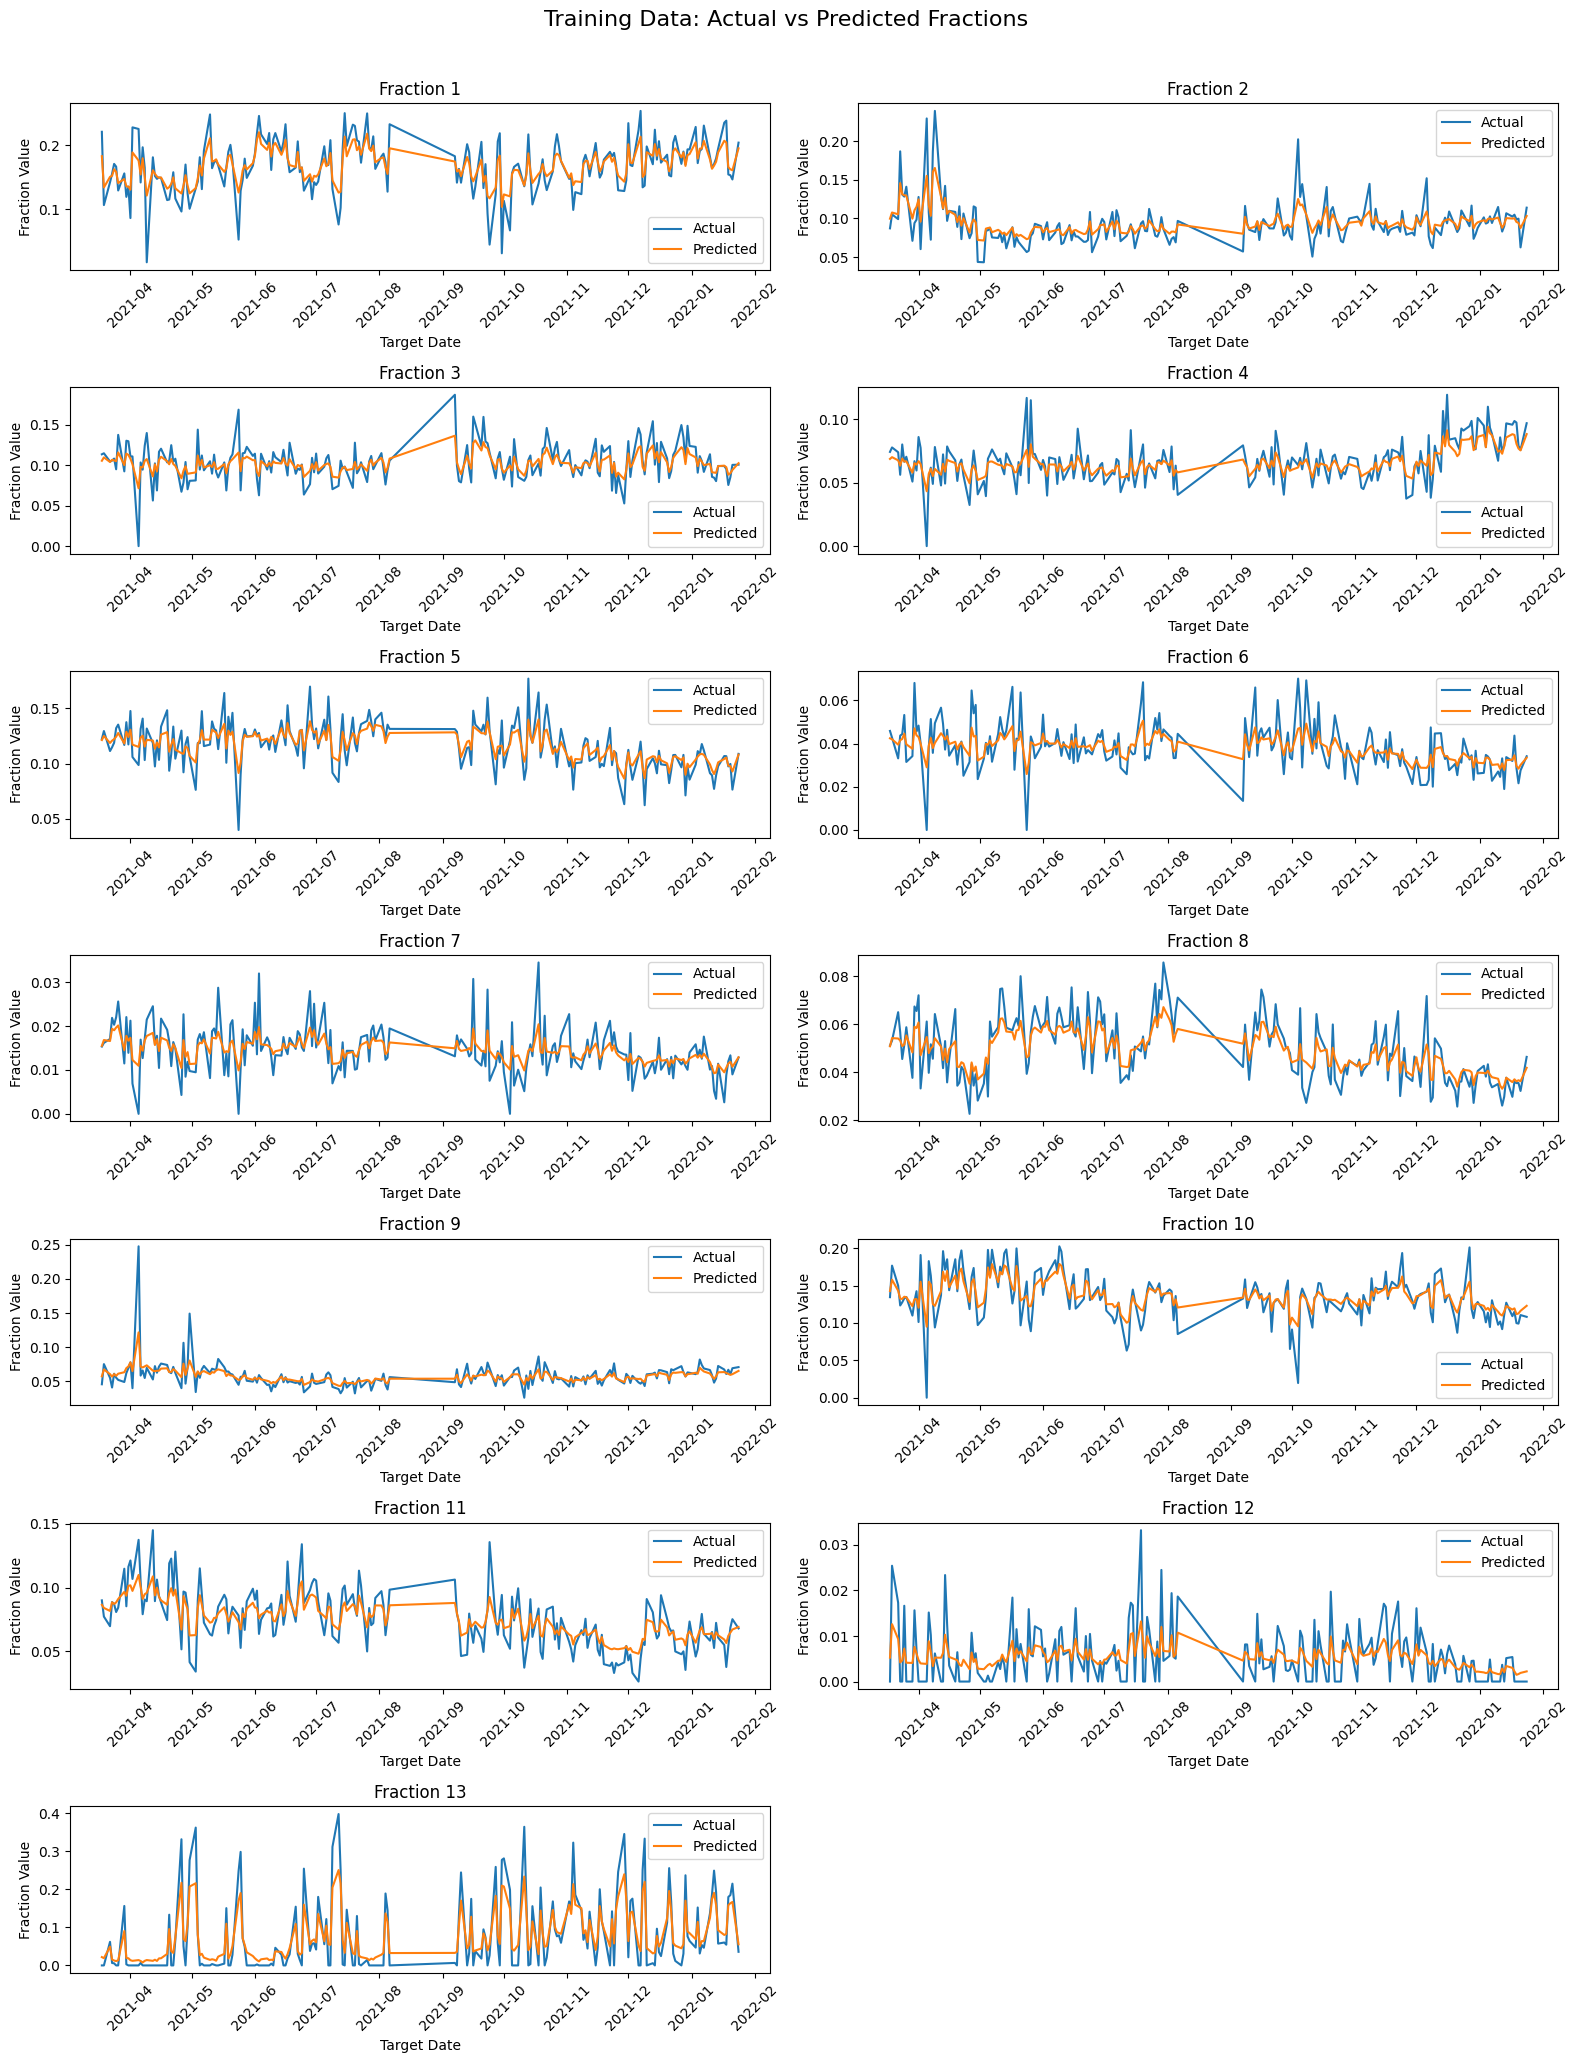

In [60]:
# =========================================================
# LINE PLOT: ACTUAL VS PREDICTED FOR ALL FRACTIONS
# =========================================================

import matplotlib.pyplot as plt
import math
import os

# Use target_date as x-axis
plot_dates = pd.to_datetime(train_df["target_date"])

# Optional: plot only first 200 rows to keep the figure readable
# If you want full training data, set max_rows = None
max_rows = 200

if max_rows is not None:
    plot_dates_to_use = plot_dates.iloc[:max_rows]
    y_true_to_use = y_train[:max_rows]
    y_pred_to_use = train_pred[:max_rows]
else:
    plot_dates_to_use = plot_dates
    y_true_to_use = y_train
    y_pred_to_use = train_pred

# Number of target fractions
n_targets = len(TARGET_SHIFT_COLS)

# Subplot layout
n_cols = 2
n_rows = math.ceil(n_targets / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows * 3),
    sharex=False
)

axes = axes.flatten()

for i, target_col in enumerate(TARGET_SHIFT_COLS):
    ax = axes[i]

    fraction_name = target_col.replace("target_frac_", "").replace(f"_h{HORIZON}", "")

    ax.plot(
        plot_dates_to_use,
        y_true_to_use[:, i],
        label="Actual",
        linewidth=1.5
    )

    ax.plot(
        plot_dates_to_use,
        y_pred_to_use[:, i],
        label="Predicted",
        linewidth=1.5
    )

    ax.set_title(f"Fraction {fraction_name}")
    ax.set_xlabel("Target Date")
    ax.set_ylabel("Fraction Value")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

# Remove empty subplots if target count is odd
for j in range(n_targets, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Training Data: Actual vs Predicted Fractions", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])


plt.show()

In [61]:
# =========================================================
# TIME SERIES CV + RANDOM SEARCH ON TRAINING DATA
# =========================================================

param_distributions = {
    "n_estimators": randint(80, 241),
    "max_depth": [8, 12, 16, None],
    "min_samples_leaf": randint(1, 6),
    "min_samples_split": randint(2, 12),
    "max_features": ["sqrt", 0.35, 0.5],
    "bootstrap": [True],
}

tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)
search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=N_RANDOM_SEARCH_ITER,
    scoring=SMAPE_SCORER,
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0,
    return_train_score=True,
)
search.fit(X_train, y_train)

cv_results = pd.DataFrame(search.cv_results_)
cv_results["mean_cv_smape"] = -cv_results["mean_test_score"]
cv_cols = [
    "rank_test_score", "mean_cv_smape", "std_test_score", "mean_train_score",
    "param_n_estimators", "param_max_depth", "param_min_samples_leaf", "param_min_samples_split", "param_max_features"
]
##cv_results[cv_cols].sort_values("rank_test_score").to_csv(os.path.join(OUTPUT_DIR, "rf_random_search_cv_results.csv"), index=False)

best_params = search.best_params_
cv_best_smape = -search.best_score_


In [63]:
# =========================================================
# VALIDATION EVALUATION
# =========================================================

best_rf = search.best_estimator_

val_pred_raw = best_rf.predict(X_val)
val_pred = postprocess_fraction_predictions(val_pred_raw)
val_smape = smape_np(y_val, val_pred)
val_per_fraction = smape_per_fraction_df(y_val, val_pred)
#val_per_fraction.to_csv(os.path.join(OUTPUT_DIR, "rf_validation_smape_per_fraction_after_tuning.csv"), index=False)


In [74]:
# =========================================================
# FINAL TEST MODEL: FIT TRAIN + VALIDATION, TEST ON HOLDOUT
# =========================================================

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = np.vstack([y_train, y_val])

final_rf = RandomForestRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
final_rf.fit(X_train_val, y_train_val)

test_pred_raw = final_rf.predict(X_test)
test_pred = postprocess_fraction_predictions(test_pred_raw)
test_smape = smape_np(y_test, test_pred)
test_per_fraction = smape_per_fraction_df(y_test, test_pred)
# Sort by SMAPE in ascending order
test_per_fraction = test_per_fraction.sort_values(
    by="SMAPE",
    ascending=True
).reset_index(drop=True)
#test_per_fraction.to_csv(os.path.join(OUTPUT_DIR, "rf_test_smape_per_fraction_after_tuning.csv"), index=False)

# Train+validation fitted model predictions on train/val/test for traceability
train_final_pred = postprocess_fraction_predictions(final_rf.predict(X_train))
val_final_pred = postprocess_fraction_predictions(final_rf.predict(X_val))

# Save predictions wide
pred_rows = []
for split_name, split_df, y_true, y_hat in [
    ("train", train_df, y_train, train_final_pred),
    ("validation", val_df, y_val, val_pred),
    ("test", test_df, y_test, test_pred),
]:
    for i in range(len(split_df)):
        row = {
            "split": split_name,
            "origin_date": split_df.iloc[i][DATE_COL],
            "target_date": split_df.iloc[i]["target_date"],
        }
        for j, col in enumerate(FRACTION_COLS):
            row[f"actual_{col}"] = y_true[i, j]
            row[f"pred_{col}"] = y_hat[i, j]
            row[f"smape_{col}"] = smape_np([y_true[i, j]], [y_hat[i, j]])
        row["row_mean_smape"] = np.mean([row[f"smape_{col}"] for col in FRACTION_COLS])
        pred_rows.append(row)
pred_df = pd.DataFrame(pred_rows)
#pred_df.to_csv(os.path.join(OUTPUT_DIR, "rf_predictions_train_validation_test.csv"), index=False)

# Long error table for test boxplot
test_long_rows = []
for i in range(len(test_df)):
    for j, col in enumerate(FRACTION_COLS):
        test_long_rows.append({
            "origin_date": test_df.iloc[i][DATE_COL],
            "target_date": test_df.iloc[i]["target_date"],
            "fraction": col,
            "actual": y_test[i, j],
            "prediction": test_pred[i, j],
            "SMAPE": smape_np([y_test[i, j]], [test_pred[i, j]])
        })
test_error_long = pd.DataFrame(test_long_rows)
#test_error_long.to_csv(os.path.join(OUTPUT_DIR, "rf_test_smape_error_long_after_tuning.csv"), index=False)

# Feature importance
fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_rf.feature_importances_
}).sort_values("importance", ascending=False)
#fi.to_csv(os.path.join(OUTPUT_DIR, "rf_feature_importance_after_tuning.csv"), index=False)

# Summary
summary = pd.DataFrame([
    {"stage": "base_train_before_tuning", "SMAPE": train_smape},
    {"stage": "best_cv_on_train", "SMAPE": cv_best_smape},
    {"stage": "validation_after_tuning", "SMAPE": val_smape},
    {"stage": "test_after_refit_train_validation", "SMAPE": test_smape},
])
#summary.to_csv(os.path.join(OUTPUT_DIR, "rf_pipeline_summary.csv"), index=False)

# Console output
print("DONE")
#print("Output dir:", OUTPUT_DIR)
print("Supervised rows:", len(model_df))
print("Features:", len(feature_cols))
print("Best params:", best_params)
print("SMAPE summary:")
print(summary)
print("Top 10 features:")
print(fi.head(10))
print("Test SMAPE per fraction:")
print(test_per_fraction)

DONE
Supervised rows: 950
Features: 662
Best params: {'bootstrap': True, 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 231}
SMAPE summary:
                               stage      SMAPE
0           base_train_before_tuning  22.994019
1                   best_cv_on_train  31.595530
2            validation_after_tuning  40.487555
3  test_after_refit_train_validation  39.100177
Top 10 features:
                    feature  importance
166      frac_1_roll_max_63    0.009914
355    frac_13_roll_mean_63    0.008131
534   frac_11_roll_range_63    0.007882
163     frac_1_roll_mean_63    0.007254
371   frac_1_roll_median_63    0.007224
531  frac_11_roll_median_63    0.007056
159     frac_1_roll_mean_21    0.006438
356     frac_13_roll_std_63    0.005992
165      frac_1_roll_min_63    0.005534
323    frac_11_roll_mean_63    0.005234
Test SMAPE per fraction:
   fraction       SMAPE
0         5   10.127438
1        10   11.426129
2        

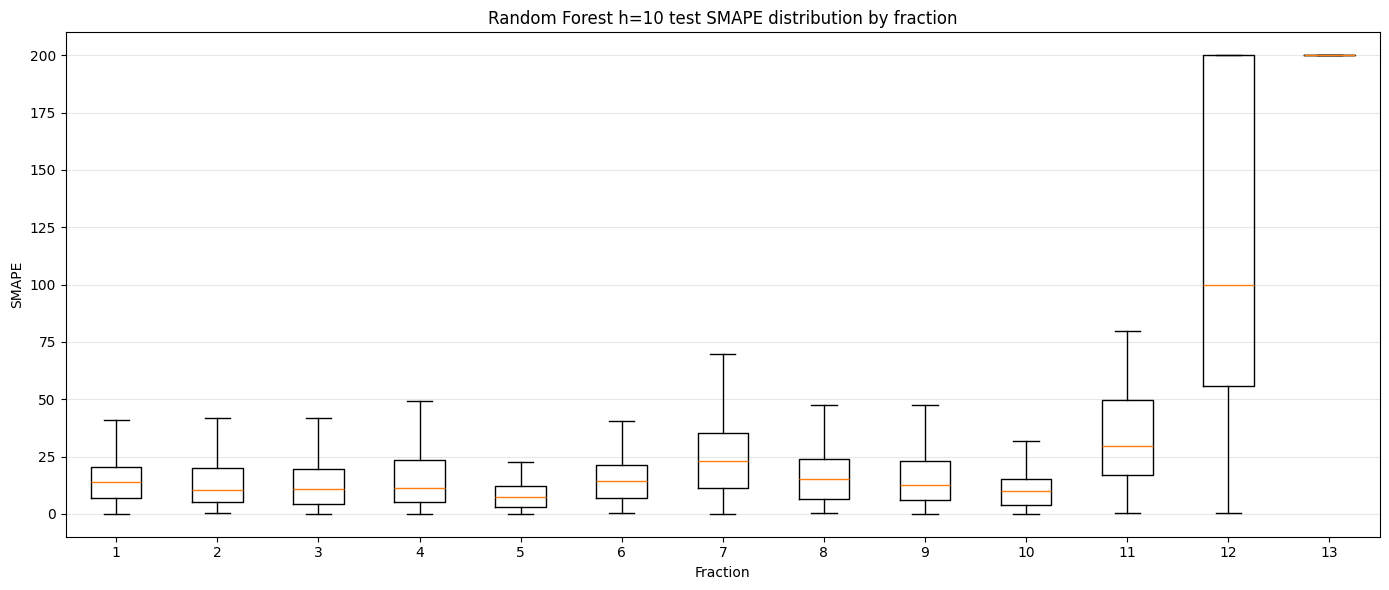

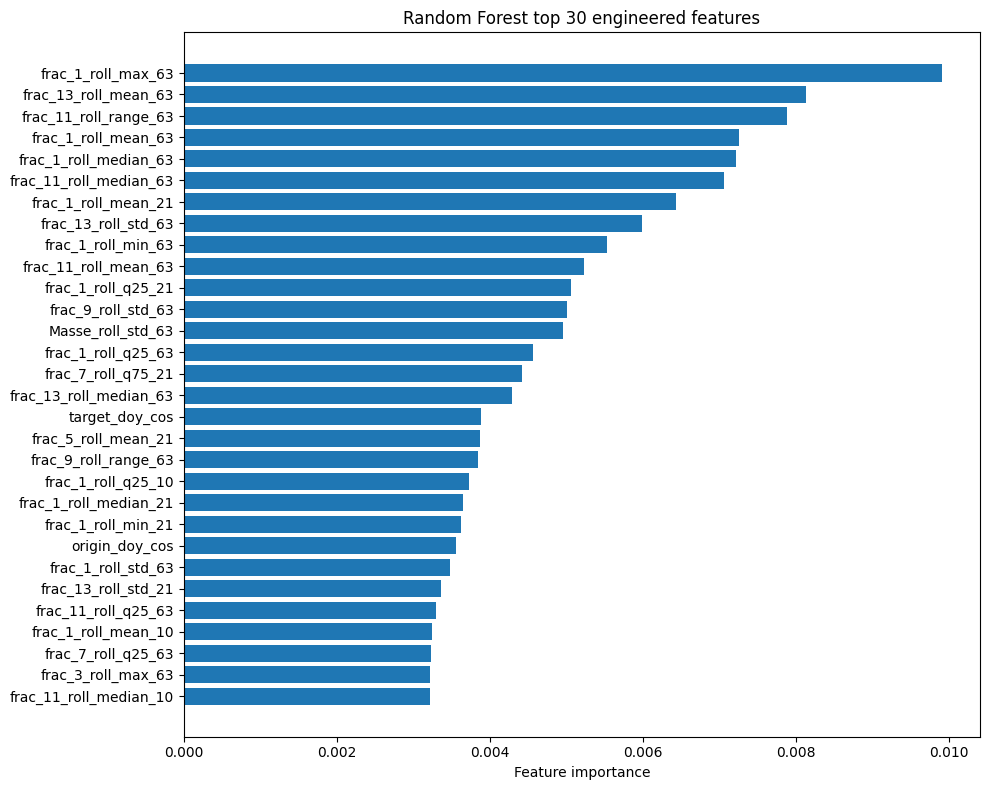

In [73]:
# Plot boxplot by fraction
plt.figure(figsize=(14, 6))
box_data = [test_error_long[test_error_long["fraction"] == col]["SMAPE"].values for col in FRACTION_COLS]
plt.boxplot(box_data, labels=FRACTION_COLS, showfliers=False)
plt.xlabel("Fraction")
plt.ylabel("SMAPE")
plt.title("Random Forest h=10 test SMAPE distribution by fraction")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, "rf_test_smape_boxplot_by_fraction_after_tuning.png"), dpi=200)
plt.show()


# Plot feature importance top 30
plt.figure(figsize=(10, 8))
top = fi.head(30).iloc[::-1]
plt.barh(top["feature"], top["importance"])
plt.xlabel("Feature importance")
plt.title("Random Forest top 30 engineered features")
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, "rf_top30_feature_importance_after_tuning.png"), dpi=200)
plt.show()

